## Chapter 6: Finetuning LLM for Text Classification

In [107]:
# printing package versions used in the notebook
from importlib.metadata import version

pkgs = [
    "torch",
    "matplotlib",
    "numpy",
    "tiktoken",
    "tensorflow",        # for loading OpenAI's weights
    "pandas"             # Dataset loading
]

for pkg in pkgs:
    print(f"{pkg} version: {version(pkg)}")

torch version: 2.9.1+cu130
matplotlib version: 3.10.7
numpy version: 2.3.5
tiktoken version: 0.12.0
tensorflow version: 2.20.0
pandas version: 2.3.3


In [108]:
import torch

print(f"Is GPU available: {torch.cuda.is_available()}")

Is GPU available: True


- Stages in finetuning a LLM:

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch06_compressed/04.webp" width=500px>

### 6.1 Different types of finetuning

- The most common ways to finetune language models are:
    - classification finetuning
    - instruction-finetuning 

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch06_compressed/02.webp" width=500px>

- Classification finetuning is similar to training a convolutional network to classify handwritten digits, for example
- In classification finetuning, we have a specific number of class labels (for example, "spam" and "not spam") that the model can output
- A classification finetuned model can only predict classes it has seen during training (for example, "spam" or "not spam"), whereas an instruction-finetuned model can usually perform many tasks
- Classification-finetuned model is analogous to very specialized model, in practice, it is much easier to create a specialized model than a generalist model that performs well on many different tasks

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch06_compressed/03.webp" width=400px>

### 6.2 Dataset preparation

#### 6.2.1 Downloading dataset

In [109]:
import requests
import zipfile
import os
from pathlib import Path

url = "https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip"
zip_path = "sms_spam_collection.zip"
extracted_path = "sms_spam_collection"
data_file_path = Path(extracted_path) / "SMSSpamCollection.tsv"


def download_and_unzip_spam_data(url, zip_path, extracted_path, data_file_path):
    if data_file_path.exists():
        print(f"{data_file_path} already exists. Skipping download and extraction.")
        return

    # Downloading the file
    response = requests.get(url, stream=True, timeout=60)
    response.raise_for_status()
    with open(zip_path, "wb") as out_file:
        for chunk in response.iter_content(chunk_size=8192):
            if chunk:
                out_file.write(chunk)

    # Unzipping the file
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(extracted_path)

    # Add .tsv file extension
    original_file_path = Path(extracted_path) / "SMSSpamCollection"
    os.rename(original_file_path, data_file_path)
    print(f"File downloaded and saved as {data_file_path}")


try:
    download_and_unzip_spam_data(url, zip_path, extracted_path, data_file_path)
except (requests.exceptions.RequestException, TimeoutError) as e:
    print(f"Primary URL failed: {e}. Trying backup URL...")
    url = "https://f001.backblazeb2.com/file/LLMs-from-scratch/sms%2Bspam%2Bcollection.zip"
    download_and_unzip_spam_data(url, zip_path, extracted_path, data_file_path)

sms_spam_collection\SMSSpamCollection.tsv already exists. Skipping download and extraction.


#### 6.2.2 Preprocessing data

In [110]:
import pandas as pd

sms_dataset = pd.read_csv(
    filepath_or_buffer = data_file_path,
    sep = "\t",              # using tab separator
    header = None,
    names = ["Label", "Message"]
)

sms_dataset

,Label,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


- When we check the class distribution, we see that the data contains "ham" (i.e., "not spam") much more frequently than "spam"

In [111]:
print(f"The count of spam & non-spam messages in the dataset is: \n{sms_dataset["Label"].value_counts()}")

The count of spam & non-spam messages in the dataset is: 
Label
ham     4825
spam     747
Name: count, dtype: int64


- The dataset contains more non-spam messages which makes it imbalanced and leads to biased training 
- Hence, there is a need for balancing the dataset
- The simplest way is to subsample(undersample)/match the counts by randomly deleting non-spam messages

In [112]:
def create_balanced_dataset(df):
    
    # Count the instances of "spam"
    num_spam = df[df["Label"] == "spam"].shape[0]
    
    # Randomly sample "ham" instances to match the number of "spam" instances
    ham_subset = df[df["Label"] == "ham"].sample(num_spam, random_state=123)
    
    # Combine ham "subset" with "spam"
    balanced_df = pd.concat([ham_subset, df[df["Label"] == "spam"]])

    return balanced_df

In [113]:
sms_dataset_balanced = create_balanced_dataset(sms_dataset)
print(f"The count of spam & non-spam messages in the balanced dataset is: \n{sms_dataset_balanced["Label"].value_counts()}")

The count of spam & non-spam messages in the balanced dataset is: 
Label
ham     747
spam    747
Name: count, dtype: int64


In [114]:
# encoding labels as integers 
sms_dataset_balanced["Label"] = sms_dataset_balanced["Label"].map({"ham": 0, "spam": 1})
sms_dataset_balanced

,Label,Message
4307,0,Awww dat is sweet! We can think of something t...
4138,0,Just got to &lt;#&gt;
4831,0,"The word ""Checkmate"" in chess comes from the P..."
4461,0,This is wishing you a great day. Moji told me ...
5440,0,Thank you. do you generally date the brothas?
...,...,...
5537,1,Want explicit SEX in 30 secs? Ring 02073162414...
5540,1,ASKED 3MOBILE IF 0870 CHATLINES INCLU IN FREE ...
5547,1,Had your contract mobile 11 Mnths? Latest Moto...
5566,1,REMINDER FROM O2: To get 2.50 pounds free call...


In [115]:
# function to random split the dataset into train, validation and test sets
def random_split(df, train_ratio, validation_ratio):
    # shuffle the dataset
    df = df.sample(frac=1, random_state=123).reset_index(drop=True)

    # calculate train and validation index
    train_end = int(len(df) * train_ratio)
    validation_end = train_end + int(len(df) * validation_ratio)

    # split the dataset into subsets
    train_df = df[:train_end]
    validation_df = df[train_end:validation_end]
    test_df = df[validation_end:]

    return train_df, validation_df, test_df

In [116]:
# create train, validation and test sets and store it as csv files
# file paths
sms_traindf_path = Path(extracted_path) / "sms_spam_train.csv" 
sms_validationdf_path = Path(extracted_path) / "sms_spam_validation.csv" 
sms_testdf_path = Path(extracted_path) / "sms_spam_test.csv" 

if sms_traindf_path.exists() and sms_validationdf_path.exists() and sms_testdf_path.exists():
    print(f"train, validaion and test sets already exists. Skipping dataset creation.")
else: 
    train_df, validation_df, test_df = random_split(sms_dataset_balanced, 0.7, 0.1)
    train_df.to_csv(f"{Path(extracted_path)}\\sms_spam_train.csv", index=None)
    validation_df.to_csv(f"{Path(extracted_path)}\\sms_spam_validation.csv", index=None)
    test_df.to_csv(f"{Path(extracted_path)}\\sms_spam_test.csv", index=None)

train, validaion and test sets already exists. Skipping dataset creation.


#### 6.2.3 Creating dataloaders

- Note that the text messages have different lengths, if we want to combine multiple training examples in a batch/Tensor thery need to have the same length, thus we have to either
  1. truncate all messages to the length of the shortest message in the dataset or batch
  2. pad all messages to the length of the longest message in the dataset or batch

- We choose option 2 and pad all messages to the longest message in the dataset
- For that, we use `<|endoftext|>` as a padding token

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch06_compressed/06.webp" width=500px>

In [117]:
import tiktoken

gpt2_tokenizer = tiktoken.get_encoding("gpt2")
print(f"The token ID of <|endoftext|> is: {gpt2_tokenizer.encode("<|endoftext|>", allowed_special={"<|endoftext|>"})}")

The token ID of <|endoftext|> is: [50256]


- The `SpamDataset` class below identifies the longest sequence in the training dataset and adds the padding token to the others to match that sequence length

In [118]:
from torch.utils.data import Dataset

class SpamDataset(Dataset):
    def __init__(self, csv_file, tokenizer, max_length=None, pad_token_id=50256):
        self.df = pd.read_csv(csv_file)

        self.encoded_texts = [
            tokenizer.encode(msg, allowed_special={"<|endoftext|>"}) 
            for msg in self.df["Message"]
        ]

        if max_length is None:
            self.max_length = self._longest_encoded_length()
        else:
            self.max_length = max_length
            # truncate text to match max length allowed
            self.encoded_texts = [
                encoded_text[:self.max_length] 
                for encoded_text in self.encoded_texts
            ]
        
        # pad the sequence with the padding token
        self.encoded_texts = [
            encoded_text + [pad_token_id] * (self.max_length - len(encoded_text))
            for encoded_text in self.encoded_texts
        ]
    
    def __getitem__(self, index):
        encoded_text = self.encoded_texts[index]
        label = self.df.iloc[index]["Label"]
        return (
            torch.tensor(encoded_text, dtype=torch.long),
            torch.tensor(label, dtype=torch.long)
        )
    
    def __len__(self):
        return len(self.df)
    
    def _longest_encoded_length(self):
        return max(len(encoded_text) for encoded_text in self.encoded_texts)
        # brute force method of finding the max length sequence 
        # max_length = 0
        # for encoded_text in self.encoded_texts:
        #     encoded_length = len(encoded_text)
        #     if encoded_length > max_length:
        #         max_length = encoded_length
        # return max_length

In [119]:
sms_train_dataset = SpamDataset(
    csv_file=sms_traindf_path,
    tokenizer=gpt2_tokenizer,
    max_length=None
)

print(f"The maximum length of sequence in train dataset is: {sms_train_dataset.max_length}")

The maximum length of sequence in train dataset is: 120


- We also pad the validation and test set to the longest training sequence
- Note that validation and test set samples that are longer than the longest training example are being truncated via `encoded_text[:self.max_length]` in the `SpamDataset` code
- This behavior is entirely optional, and it would also work well if we set `max_length=None` in both the validation and test set cases

In [120]:
sms_validation_dataset = SpamDataset(
    csv_file=sms_validationdf_path,
    tokenizer=gpt2_tokenizer,
    max_length=sms_train_dataset.max_length
)

sms_test_dataset = SpamDataset(
    csv_file=sms_testdf_path,
    tokenizer=gpt2_tokenizer,
    max_length=sms_train_dataset.max_length
)

- Instantiate dataloader with batch size of 8 using the Dataset

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch06_compressed/07.webp" width=500px>

In [121]:
from torch.utils.data import DataLoader

num_workers = 0     # multi threading for data loading
batch_size = 8

torch.manual_seed(123)

train_dataloader = DataLoader(
    dataset=sms_train_dataset,
    batch_size=batch_size,
    shuffle=True,
    drop_last=True,
    num_workers=num_workers
)

validation_dataloader = DataLoader(
    dataset=sms_validation_dataset,
    batch_size=batch_size,
    shuffle=False,
    drop_last=False,
    num_workers=num_workers
)

test_dataloader = DataLoader(
    dataset=sms_test_dataset,
    batch_size=batch_size,
    shuffle=False,
    drop_last=False,
    num_workers=num_workers
)

In [122]:
# test the data loader 
print("Train loader sample:")
for input_batch, target_batch in train_dataloader:
    pass

print("Input batch dimensions:", input_batch.shape)
print("Label batch dimensions", target_batch.shape)

# number of batches in each dataloader
print(f"\n{len(train_dataloader)} training batches")
print(f"{len(validation_dataloader)} validation batches")
print(f"{len(test_dataloader)} test batches")

Train loader sample:
Input batch dimensions: torch.Size([8, 120])
Label batch dimensions torch.Size([8])

130 training batches
19 validation batches
38 test batches


### 6.4 Initializing model with pretrained weights

In [123]:
CHOOSE_MODEL = "gpt2-small (124M)"

GPT2_BASE_CONFIG = {
    "vocab_size": 50257,     # Vocabulary size
    "contextWindow_len": 1024,  # Context length
    "dropout_rate": 0.0,        # Dropout rate
    "qkv_bias": True         # Query-key-value bias
}

model_configs = {
    "gpt2-small (124M)": {"embedding_dim": 768, "num_transformerLayers": 12, "num_heads": 12},
    "gpt2-medium (355M)": {"embedding_dim": 1024, "num_transformerLayers": 24, "num_heads": 16},
    "gpt2-large (774M)": {"embedding_dim": 1280, "num_transformerLayers": 36, "num_heads": 20},
    "gpt2-xl (1558M)": {"embedding_dim": 1600, "num_transformerLayers": 48, "num_heads": 25},
}

GPT2_BASE_CONFIG.update(model_configs[CHOOSE_MODEL])

print(f"{GPT2_BASE_CONFIG}")

assert sms_train_dataset.max_length <= GPT2_BASE_CONFIG["contextWindow_len"], (
    f"Dataset length {sms_train_dataset.max_length} exceeds model's context "
    f"length {GPT2_BASE_CONFIG['contextWindow_len']}. Reinitialize data sets with "
    f"`max_length={GPT2_BASE_CONFIG['contextWindow_len']}`"
)

{'vocab_size': 50257, 'contextWindow_len': 1024, 'dropout_rate': 0.0, 'qkv_bias': True, 'embedding_dim': 768, 'num_transformerLayers': 12, 'num_heads': 12}


In [124]:
from openai_gpt2_download import download_and_load_gpt2

# get model size from the model name
gpt2_size = CHOOSE_MODEL.split(" ")[-1].lstrip("(").rstrip(")")
settings, params = download_and_load_gpt2(model_size=gpt2_size, models_dir="..\\Ch05\\gpt2")  # using downloaded weights from Ch05 folder

print(f"\nGPT2-{gpt2_size} loaded with configs as: \n{settings}\n{params.keys()}")

File already exists and is up-to-date: ..\Ch05\gpt2\124M\checkpoint
File already exists and is up-to-date: ..\Ch05\gpt2\124M\encoder.json
File already exists and is up-to-date: ..\Ch05\gpt2\124M\hparams.json
File already exists and is up-to-date: ..\Ch05\gpt2\124M\model.ckpt.data-00000-of-00001
File already exists and is up-to-date: ..\Ch05\gpt2\124M\model.ckpt.index
File already exists and is up-to-date: ..\Ch05\gpt2\124M\model.ckpt.meta
File already exists and is up-to-date: ..\Ch05\gpt2\124M\vocab.bpe

GPT2-124M loaded with configs as: 
{'n_vocab': 50257, 'n_ctx': 1024, 'n_embd': 768, 'n_head': 12, 'n_layer': 12}
dict_keys(['blocks', 'b', 'g', 'wpe', 'wte'])


In [125]:
from previous_chapters import GPTModel, load_weights_into_gpt_instance, generate_tokens_with_sampling, text_to_token_ids, token_ids_to_text

gpt2_124m = GPTModel(GPT2_BASE_CONFIG)

# loading pre-trained weights into model instance
load_weights_into_gpt_instance(gpt2_124m, params)
gpt2_124m.eval();

# testing model with sample input
sample_input_prompt = "Every effort moves"

model_output = generate_tokens_with_sampling(
    model=gpt2_124m,
    input_ids=text_to_token_ids(input_sentence=sample_input_prompt, tokenizer=gpt2_tokenizer),
    context_window=GPT2_BASE_CONFIG["contextWindow_len"],
    max_new_tokens=25
)

print(f"GPT2 model ouput: {token_ids_to_text(token_ids=model_output, tokenizer=gpt2_tokenizer)}")

GPT2 model ouput: Every effort moves forward, but it's not enough.

"I'm not going to sit here and say, 'I'm not


- Before we finetune the model as a classifier, let's see if the model can perhaps already classify spam messages via prompting

In [126]:
sample_message_prompt = (
    "Is the following text 'spam'? Answer with 'yes' or 'no':"
    " 'You are a winner you have been specially"
    " selected to receive $1000 cash or a $2000 award.'"
)

model_output = generate_tokens_with_sampling(
    model=gpt2_124m,
    input_ids=text_to_token_ids(input_sentence=sample_message_prompt, tokenizer=gpt2_tokenizer),
    context_window=GPT2_BASE_CONFIG["contextWindow_len"],
    max_new_tokens=25
)

print(f"GPT2 model ouput: {token_ids_to_text(token_ids=model_output, tokenizer=gpt2_tokenizer)}")

GPT2 model ouput: Is the following text 'spam'? Answer with 'yes' or 'no': 'You are a winner you have been specially selected to receive $1000 cash or a $2000 award.'

The following text 'spam'? Answer with 'yes' or 'no': 'You are a winner you have


### 6.5 Modify model for finetuning

- we are modifying the pretrained LLM to make it ready for classification finetuning

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch06_compressed/09.webp" width=500px>

In [127]:
# current model architecture 
gpt2_124m

GPTModel(
  (token_embedding_layer): Embedding(50257, 768)
  (position_embedding_layer): Embedding(1024, 768)
  (dropout_layer): Dropout(p=0.0, inplace=False)
  (transformer_blocks): Sequential(
    (0): TransformerBlock(
      (attention_layer): MultiHeadAttention(
        (W_queries): Linear(in_features=768, out_features=768, bias=True)
        (W_keys): Linear(in_features=768, out_features=768, bias=True)
        (W_values): Linear(in_features=768, out_features=768, bias=True)
        (projection): Linear(in_features=768, out_features=768, bias=True)
        (dropout_layer): Dropout(p=0.0, inplace=False)
      )
      (layerNorm1): LayerNorm()
      (layerNorm2): LayerNorm()
      (feedForward_layer): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (dropout_layer): Dropout(p=0.0, inplace=False)
    )
    (1

In [128]:
# freezing the model parameters in order not to change them while training(making them non-trainable)
for prarameter in gpt2_124m.parameters():
    prarameter.requires_grad = False

- We replace the output layer (`model.output_head`), which originally maps the layer inputs to 50,257 dimensions (the size of the vocabulary)
- Since we finetune the model for binary classification (predicting 2 classes, "spam" and "not spam"), we can replace the output layer as shown below, which will be trainable by default because of Linear layer class

In [129]:
torch.manual_seed(123)

num_classes = 2     # change according to classification categories required for the problem
# replacing the final layer to (768 x 2) 
gpt2_124m.output_head = torch.nn.Linear(GPT2_BASE_CONFIG["embedding_dim"], num_classes)
print(f"output layer of model is: {gpt2_124m.output_head}")

output layer of model is: Linear(in_features=768, out_features=2, bias=True)


- Technically, it's sufficient to only train the output layer
- However, as mentioned in [Finetuning Large Language Models](https://magazine.sebastianraschka.com/p/finetuning-large-language-models), experiments show that finetuning additional layers can noticeably improve the performance
- So, unfreezing the last transformer block and the final `LayerNorm` module connecting the last transformer block to the output layer and making them trainable

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch06_compressed/10.webp" width=500px>

In [130]:
# unfreezing the last transformer block and final layernorm to be included in the training
# finalnorm
for parameter in gpt2_124m.final_norm.parameters():
    parameter.requires_grad = True

# Last transformer block
for prarameter in gpt2_124m.transformer_blocks[-1].parameters():
    parameter.requires_grad = True

In [131]:
sample_input_prompt = "Do you have time"

encoded_text = gpt2_tokenizer.encode(sample_input_prompt, allowed_special={"<|endoftext|>"})
encoded_text = torch.tensor(encoded_text).unsqueeze(0)      # adding batch dimension 
print(f"The input token ids with dimesnsions {encoded_text.shape} are: {encoded_text}\n")

model_output = gpt2_124m(encoded_text)
print(f"The corresponeding model output with dimensions {model_output.shape} is: \n{model_output}")

The input token ids with dimesnsions torch.Size([1, 4]) are: tensor([[5211,  345,  423,  640]])

The corresponeding model output with dimensions torch.Size([1, 4, 2]) is: 
tensor([[[-1.5854,  0.9904],
         [-3.7235,  7.4548],
         [-2.2661,  6.6049],
         [-3.5983,  3.9902]]], grad_fn=<ViewBackward0>)


- We can still use this model similar to before, the only difference is that it now has two output dimensions instead of 50,257
- As discussed before, for each input token, there's one output vector given by model
- Since we fed the model a text sample with 4 input tokens, the output consists of 4 2-dimensional output vectors

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch06_compressed/11.webp" width=500px>

- The attention mechanism, which connects each input token to each other input token
- The causal attention mask that is used in GPT-like models, this causal mask lets a current token only attend to the current and previous token positions
- Based on this causal attention mechanism, the 4th (last) token contains the most information among all tokens because it's the only token that includes information about all other tokens
- Hence, we are particularly interested in this last token, which we will finetune for the spam classification task

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch06_compressed/12.webp" width=200px>

In [132]:
print(f"The output logit corresponding to last token is: {model_output[:, -1, :]}")

The output logit corresponding to last token is: tensor([[-3.5983,  3.9902]], grad_fn=<SelectBackward0>)


### 6.6 Calculating classification loss and accuracy

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch06_compressed/14.webp" width=600px>

- we convert the outputs (logits) into probability scores via the `softmax` function and then obtain the index position of the largest probability value via the `argmax` function
- Note that the softmax function is optional here, because the largest outputs correspond to the largest probability scores

In [133]:
probabilities = torch.softmax(model_output[:, -1, :], dim=-1)
label = torch.argmax(probabilities, dim=-1)
print(f"Predicted class label is: {label.item()}")

Predicted class label is: 1


In [134]:
logits = model_output[:, -1, :]
label = torch.argmax(logits)
print(f"Predicted class label is: {label.item()}")

Predicted class label is: 1


In [135]:
def calc_accuracy_dataloader(dataloader, model, device, num_batches=None):
    model.eval()
    correct_predictions, num_samples = 0, 0

    if num_batches is None:
        num_batches = len(dataloader)
    else: 
        num_batches = min(num_batches, len(dataloader))
    
    for i, (input_batch, target_batch) in enumerate(dataloader):
        if i < num_batches:
            input_batch, target_batch = input_batch.to(device), target_batch.to(device)

            with torch.no_grad():
                logits = model(input_batch)[:, -1, :]
            predicted_labels = torch.argmax(logits, dim=-1)
            
            num_samples += predicted_labels.shape[0]
            correct_predictions += (predicted_labels == target_batch).sum().item()
        else:
            break
    
    return correct_predictions / num_samples

In [136]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    # Use PyTorch 2.9 or newer for stable mps results
    major, minor = map(int, torch.__version__.split(".")[:2])
    if (major, minor) >= (2, 9):
        device = torch.device("mps")
    else:
        device = torch.device("cpu")
else:
    device = torch.device("cpu")

print("Device:", device)

gpt2_124m.to(device) # no assignment model = model.to(device) necessary for nn.Module classes

torch.manual_seed(123) # For reproducibility due to the shuffling in the training data loader

train_accuracy = calc_accuracy_dataloader(train_dataloader, gpt2_124m, device, num_batches=10)
val_accuracy = calc_accuracy_dataloader(validation_dataloader, gpt2_124m, device, num_batches=10)
test_accuracy = calc_accuracy_dataloader(test_dataloader, gpt2_124m, device, num_batches=10)

print(f"Training accuracy: {train_accuracy*100:.2f}%")
print(f"Validation accuracy: {val_accuracy*100:.2f}%")
print(f"Test accuracy: {test_accuracy*100:.2f}%")

Device: cuda
Training accuracy: 46.25%
Validation accuracy: 45.00%
Test accuracy: 48.75%


In [137]:
# utiltiy functions to calculate loss for each batch 
def calc_loss_batch(input_data, target_data, model, device):
    # loading data to the same device as model
    input_data, target_data = input_data.to(device), target_data.to(device)
    logits = model(input_data)[:, -1, :]            # need loss for only last logit
    cross_entropy_loss = torch.nn.functional.cross_entropy(logits, target_data)
    return cross_entropy_loss

# utility function to calculate loss for entire dataset
def calc_loss_dataloader(input_dataloader, model, device, num_batches = None):
    total_loss = 0.
    if len(input_dataloader) == 0:
        return float("nan")
    elif num_batches is None:
        num_batches = len(input_dataloader)
    else: 
        # if num_batches passed exceeds the number of batches in the data loader or less than the number in data loader 
        # change the number of batches to match the total number of batches in the data loader or num_batches passed whichever is minimum
        num_batches = min(num_batches, len(input_dataloader))
    for i, (x, y) in enumerate(input_dataloader):
        if i < num_batches:
            batch_loss = calc_loss_batch(x, y, model, device)
            total_loss += batch_loss.item()
        else:
            break

    return total_loss / num_batches     # returning average loss over the dataset

- The goal is to maximize the spam classification accuracy of the model. However, classification accuracy is not a differentiable function
- Hence, instead, we minimize the cross-entropy loss as a proxy for maximizing the classification accuracy (refer [Introduction to Deep Learning](https://sebastianraschka.com/blog/2021/dl-course.html#l08-multinomial-logistic-regression--softmax-regression) class)

- The `calc_loss_batch` function is the same here as in pre-training, except that we are only interested in optimizing the last token `model(input_batch)[:, -1, :]` instead of all tokens `model(input_batch)`

In [138]:
with torch.no_grad(): # Disable gradient tracking for efficiency because we are not training, yet
    train_loss = calc_loss_dataloader(train_dataloader, gpt2_124m, device, num_batches=5)
    val_loss = calc_loss_dataloader(validation_dataloader, gpt2_124m, device, num_batches=5)
    test_loss = calc_loss_dataloader(test_dataloader, gpt2_124m, device, num_batches=5)

print(f"Training loss: {train_loss:.3f}")
print(f"Validation loss: {val_loss:.3f}")
print(f"Test loss: {test_loss:.3f}")

Training loss: 2.453
Validation loss: 2.583
Test loss: 2.322


### 6.7 Finetuning model on supervised data

In [139]:
# utility function to evaluate model
def evaluate_training(model, train_dataloader, validation_dataloader, device, num_eval_batches):
    model.eval()
    with torch.no_grad():
        eval_train_loss = calc_loss_dataloader(train_dataloader, model, device, num_eval_batches)
        eval_validation_loss = calc_loss_dataloader(validation_dataloader, model, device, num_eval_batches)
    return eval_train_loss, eval_validation_loss

- The `classifier_model_training` function below is practically the same as the `model_training_simple` function we used for pretraining the model
- The only two differences are that we now 
  1. track the number of training examples seen (`num_records_seen`) instead of the number of tokens seen
  2. calculate the accuracy after each epoch instead of printing a sample text after each epoch

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch06_compressed/15.webp" width=500px>

In [140]:
# simple training class to train an LLM
def classifier_model_training(
        model,
        train_dataloader,
        validation_dataloader,
        optimizer,
        device,
        num_epochs,
        eval_frequency,     # defining the frequency of model evaluation(if n, evaluate model after every n iteration)
        eval_batch_iteration     # controls the number of batches used for evaluation
    ):
    train_loss, validation_loss = [], []
    train_accuracies, validation_accuracies = [], []
    num_records_seen, global_step = 0, -1

    # iterating over the entire dataset for `num_epochs` time
    for epoch in range(num_epochs):
        model.train()

        # iterating over the training data with each batch as one step in training
        for input_batch, target_batch in train_dataloader:
            optimizer.zero_grad()        # Reset gradients to zero 
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            loss.backward()             # Calculate loss gradients
            optimizer.step()            # update weights based on loss gradients
            num_records_seen += input_batch.shape[0]
            global_step += 1

            # evaluate model if number of steps reaches the frequency of evaluation(ex: for every 5th step)
            if global_step % eval_frequency == 0:
                step_training_loss, step_validation_loss = evaluate_training(
                    model, train_dataloader, validation_dataloader, device, eval_batch_iteration
                )
                train_loss.append(step_training_loss)
                validation_loss.append(step_validation_loss)
                print(f"Epoch {epoch + 1} [Step {global_step:05d}]:"
                      f"\tTraining Loss: {step_training_loss:.3f} \t Validation Loss: {step_validation_loss:.3f}")
        
        # calculate accuracies after each epoch with a subset of batches(using eval_batch_iteration)
        train_accuracy = calc_accuracy_dataloader(train_dataloader, model, device, eval_batch_iteration)
        validation_accuracy = calc_accuracy_dataloader(validation_dataloader, model, device, eval_batch_iteration)

        print(f"\nTraining accuracy: {train_accuracy*100:.2f}% | ", end="")
        print(f"Validation accuracy: {validation_accuracy*100:.2f}%")
        print(f"="* 75)

        train_accuracies.append(train_accuracy)
        validation_accuracies.append(validation_accuracy)

    return train_loss, validation_loss, train_accuracies, validation_accuracies, num_records_seen

In [141]:
torch.save(gpt2_124m.state_dict(), "gpt2small_before_finetuning.pth")

In [184]:
load_checkpoint = torch.load("gpt2small_before_finetuning.pth", map_location=device, weights_only=True)
gpt2_124m.load_state_dict(load_checkpoint)

<All keys matched successfully>

In [194]:
# estimating time for training LLM
import time
start_time = time.time()

# Initiate model and optimizer
torch.manual_seed(123)

adam_optimizer = torch.optim.AdamW(gpt2_124m.parameters(), lr=5e-5, weight_decay=0.1)

n_epochs = 4
# Initiate a LLM training 
training_losses, validation_losses, training_accuracies, validation_accuracies, totalrecords = classifier_model_training(
    model = gpt2_124m,
    train_dataloader = train_dataloader,
    validation_dataloader = validation_dataloader,
    optimizer = adam_optimizer,
    device = device,
    num_epochs = n_epochs,
    eval_frequency = 50,
    eval_batch_iteration = 10
)

end_time = time.time()
execution_time_minutes = (end_time - start_time) / 60
print(f"\nTraining completed in {execution_time_minutes:.2f} minutes.")

Epoch 1 [Step 00000]:	Training Loss: 0.356 	 Validation Loss: 0.343
Epoch 1 [Step 00050]:	Training Loss: 0.394 	 Validation Loss: 0.357
Epoch 1 [Step 00100]:	Training Loss: 0.363 	 Validation Loss: 0.365

Training accuracy: 86.25% | Validation accuracy: 90.00%
Epoch 2 [Step 00150]:	Training Loss: 0.347 	 Validation Loss: 0.342
Epoch 2 [Step 00200]:	Training Loss: 0.352 	 Validation Loss: 0.355
Epoch 2 [Step 00250]:	Training Loss: 0.413 	 Validation Loss: 0.345

Training accuracy: 86.25% | Validation accuracy: 88.75%
Epoch 3 [Step 00300]:	Training Loss: 0.311 	 Validation Loss: 0.344
Epoch 3 [Step 00350]:	Training Loss: 0.346 	 Validation Loss: 0.342

Training accuracy: 82.50% | Validation accuracy: 83.75%
Epoch 4 [Step 00400]:	Training Loss: 0.306 	 Validation Loss: 0.386
Epoch 4 [Step 00450]:	Training Loss: 0.390 	 Validation Loss: 0.344
Epoch 4 [Step 00500]:	Training Loss: 0.331 	 Validation Loss: 0.345

Training accuracy: 95.00% | Validation accuracy: 88.75%

Training completed in 1

In [195]:
import matplotlib.pyplot as plt

def plot_values(epochs_seen, records_seen, train_values, val_values, label="loss"):
    fig, ax1 = plt.subplots(figsize=(5, 3))

    # Plot training and validation loss against epochs
    ax1.plot(epochs_seen, train_values, label=f"Training {label}")
    ax1.plot(epochs_seen, val_values, linestyle="-.", label=f"Validation {label}")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel(label.capitalize())
    ax1.legend()

    # Create a second x-axis for examples seen
    ax2 = ax1.twiny()  # Create a second x-axis that shares the same y-axis
    ax2.plot(records_seen, train_values, alpha=0)  # Invisible plot for aligning ticks
    ax2.set_xlabel("Records seen")

    fig.tight_layout()  # Adjust layout to make room
    # plt.savefig(f"{label}-plot.pdf")
    plt.show()

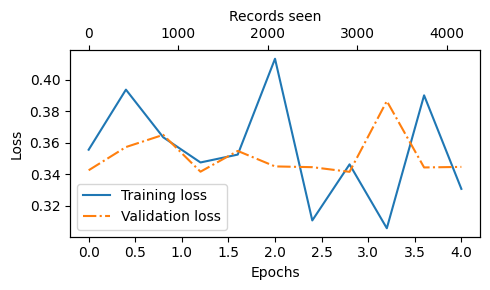

In [196]:
# plot training loss graph
epochs_tensor = torch.linspace(0, n_epochs, len(training_losses))
records_seen_tensor = torch.linspace(0, totalrecords, len(training_losses))

plot_values(epochs_tensor, records_seen_tensor, training_losses, validation_losses)

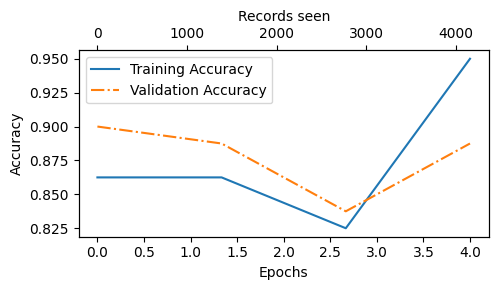

In [197]:
# plot training accuracy graph
epochs_tensor = torch.linspace(0, n_epochs, len(training_accuracies))
records_seen_tensor = torch.linspace(0, totalrecords, len(training_accuracies))

plot_values(epochs_tensor, records_seen_tensor, training_accuracies, validation_accuracies, label="Accuracy")

In [198]:
train_accuracy = calc_accuracy_dataloader(train_dataloader, gpt2_124m, device, num_batches=10)
val_accuracy = calc_accuracy_dataloader(validation_dataloader, gpt2_124m, device, num_batches=10)
test_accuracy = calc_accuracy_dataloader(test_dataloader, gpt2_124m, device, num_batches=10)

print(f"Training accuracy: {train_accuracy*100:.2f}%")
print(f"Validation accuracy: {val_accuracy*100:.2f}%")
print(f"Test accuracy: {test_accuracy*100:.2f}%")

Training accuracy: 86.25%
Validation accuracy: 88.75%
Test accuracy: 87.50%


### 6.8 Using finetuned LLM as spam classifier

In [199]:
# Utility function to use the model for spam classification
def classify_message(model, input, tokenizer, device, max_length=None, pad_token_id=50256):
    model.eval()

    input_tokenIds = tokenizer.encode(input, allowed_special={"<|endoftext|>"})
    model_context_length = model.position_embedding_layer.weight.shape[0]

    if max_length is None:
        max_length = model_context_length
    else:
        max_length = min(model_context_length, max_length)
    
    # truncate the inputs token ids to match the max length supported if they are long
    input_tokenIds = input_tokenIds[:max_length]
    # extend the input token ids to match max length supported if they are short
    input_tokenIds += [pad_token_id] * (max_length - len(input_tokenIds))
    input_tensor = torch.tensor(input_tokenIds, device=device).unsqueeze(0)

    with torch.no_grad():
        logits = model(input_tensor)[:, -1, :]
    predicted_label = torch.argmax(logits, dim=-1).item()

    return "spam" if predicted_label == 1 else "not spam"

In [205]:
sample_message_prompt1 = (
    "You are a winner you have been specially"
    " selected to receive $1000 cash or a $2000 award."
)

print(classify_message(
    gpt2_124m, sample_message_prompt1, gpt2_tokenizer, device, max_length=sms_train_dataset.max_length
))

not spam


In [203]:
sample_message_prompt2 = (
    "Hey, just wanted to check if we're still on"
    " for dinner tonight? Let me know!"
)

print(classify_message(
    gpt2_124m, sample_message_prompt2, gpt2_tokenizer, device, max_length=sms_train_dataset.max_length
))

not spam


In [204]:
sample_message_prompt3 = (
    "You have been specially selected to receive a "
    "3000 award! Call 08712402050 BEFORE the lines close. Cost 10ppm. 16+. T&Cs apply. AG Promo"
)

print(classify_message(
    gpt2_124m, sample_message_prompt3, gpt2_tokenizer, device, max_length=sms_train_dataset.max_length
))

spam


In [206]:
# save model to reuse
torch.save(gpt2_124m.state_dict(), "spam_classifier.pth")

In [207]:
model_state_dict = torch.load("spam_classifier.pth", map_location=device, weights_only=True)
gpt2_124m.load_state_dict(model_state_dict)
gpt2_124m

GPTModel(
  (token_embedding_layer): Embedding(50257, 768)
  (position_embedding_layer): Embedding(1024, 768)
  (dropout_layer): Dropout(p=0.0, inplace=False)
  (transformer_blocks): Sequential(
    (0): TransformerBlock(
      (attention_layer): MultiHeadAttention(
        (W_queries): Linear(in_features=768, out_features=768, bias=True)
        (W_keys): Linear(in_features=768, out_features=768, bias=True)
        (W_values): Linear(in_features=768, out_features=768, bias=True)
        (projection): Linear(in_features=768, out_features=768, bias=True)
        (dropout_layer): Dropout(p=0.0, inplace=False)
      )
      (layerNorm1): LayerNorm()
      (layerNorm2): LayerNorm()
      (feedForward_layer): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (dropout_layer): Dropout(p=0.0, inplace=False)
    )
    (1